In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import glob
import math
from matplotlib import pyplot as plt
import json
from matplotlib.ticker import MaxNLocator

In [3]:
def read_json_file(file_loc):
    with open(f"{file_loc}/runhistory.json") as f:
        runhistory = json.load(f)
    with open(f"{file_loc}/intensifier.json") as f:
        intensifier = json.load(f)

    return runhistory, intensifier


hist, inten = read_json_file("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

print(len(hist["configs"]))

6


In [4]:
def makeline_plot_over_time(file_loc):
    hist, inten = read_json_file(file_loc)

    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    # Actually not compltely fair as we might compare 1 and 2 on 2 instances and then 1 wins, but later the average still becomes lower

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])


    runt_arr = [np.mean(all_runtimes) for all_runtimes in all_config_runtimes.values()]
    cost_arr = [np.mean(all_runtimes) for all_runtimes in all_config_cost.values()]


    how_many = [len(all_runtimes) for all_runtimes in all_config_cost.values()]

    plt.plot(runt_arr)
    plt.xlabel("Config")
    plt.ylabel("Average Runtime")
    plt.show()
    plt.plot(cost_arr)
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")
    plt.show()

    plt.bar(list(range(0, n_configs)), how_many)
    plt.xlabel("Config")
    plt.ylabel("Instances evaluated")
    plt.show()



In [5]:
def get_smac_lines(file_loc):

    hist, inten = read_json_file(file_loc)
    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])


    runt_arr = [np.mean(all_runtimes) for all_runtimes in all_config_runtimes.values()]
    cost_arr = [np.mean(all_runtimes) for all_runtimes in all_config_cost.values()]


    how_many = [len(all_runtimes) for all_runtimes in all_config_cost.values()]

    return runt_arr, cost_arr

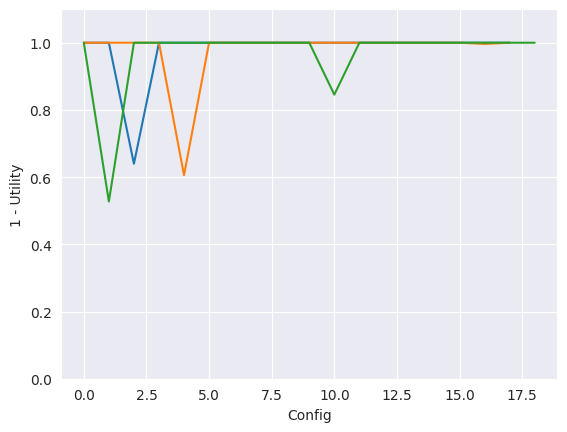

In [6]:
all_run = []
all_cost = []
n_configs_total = []

for i in range(1, 4):
    runt_array, cost_array = get_smac_lines(f"./wand_storage/SMAC/smac3_mipverify_utility_9600_instance152_new_intesifier_final3/{i}")

    plt.plot(cost_array, label=f"Run_{i}")

plt.ylim([0,1.1])
plt.xlabel("Config")
plt.ylabel("1 - Utility")
plt.show()


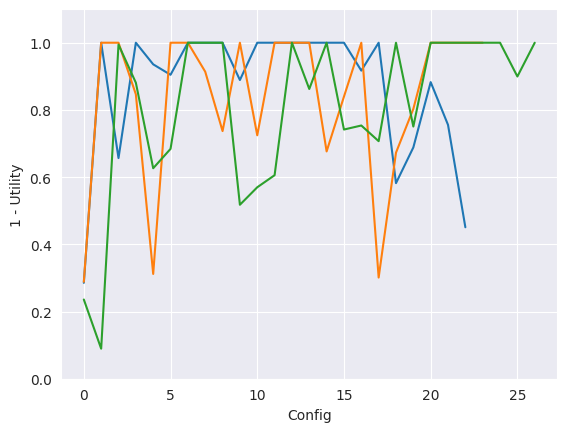

In [7]:
all_run = []
all_cost = []
n_configs_total = []

for i in range(1, 4):
    runt_array, cost_array = get_smac_lines(f"./wand_storage/SMAC/smac3_mipverify_utility_9600_instance566_new_intesifier_final3/{i}")

    plt.plot(cost_array, label=f"Run_{i}")

plt.ylim([0,1.1])
plt.xlabel("Config")
plt.ylabel("1 - Utility")
plt.show()


[0.2698488481438765 0.6964645389481685 0.8837032035319262
 0.9091772449492685 0.6246447135884842 0.8628753484827048 1.0
 0.9712604155349313 0.9123456557116126 0.8022442230675365
 0.7647393411607907 0.8685697785924796 1.0 0.9541267419699473
 0.892151376747977 0.8604327691492415 0.8902035470372526
 0.6693735752687542 0.7516008281330165 0.7473081478721283
 0.9609159417700192 0.9185091714161281 0.8169275198793717 1.0 1.0
 0.8994993652506362 1.0]


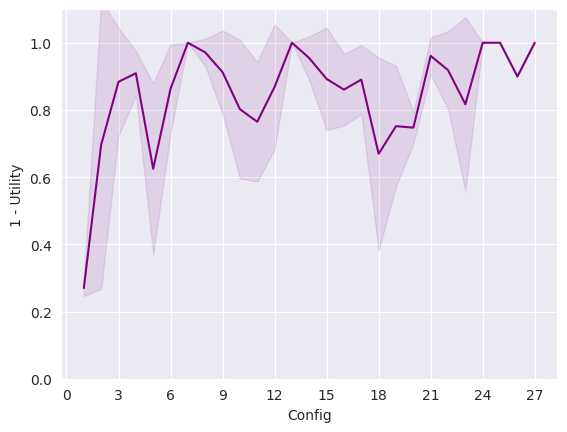

In [8]:
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)


def make_conf_plot(file_loc):
    all_run = []
    all_cost = []
    n_configs_total = []

    for i in range(1, 4):
        runt_array, cost_array = get_smac_lines(f"{file_loc}/{i}")
        all_run.append(runt_array)
        all_cost.append(cost_array)


    y, error = tolerant_mean(all_cost)
    print(y)
    # ax.plot(np.arange(len(y))+1, y, color='green')

    ax = plt.figure().gca()

    ax.plot(np.arange(len(y))+1, y, color='purple')
    ax.fill_between(np.arange(len(y))+1, (y-error), (y+error), color='purple', alpha=.1)
    # plt.plot(cost_array, label=f"Run_{i}")

    plt.ylim([0,1.1])
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")

    # plt.xticks(np.arange(len(y))+1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

make_conf_plot("./wand_storage/SMAC/smac3_mipverify_utility_9600_instance566_new_intesifier_final3/")


[1.0 0.8425136516225038 0.8799555028135009 1.0 0.8686263136193983 1.0 1.0
 1.0 1.0 1.0 0.948522313131385 1.0 1.0 1.0 1.0 1.0 0.9987700277969607 1.0
 1.0]


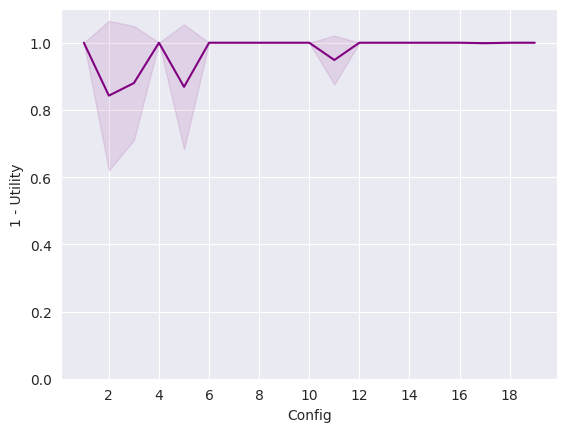

In [9]:
make_conf_plot("./wand_storage/SMAC/smac3_mipverify_utility_9600_instance152_new_intesifier_final3/")

# CASMO Full DoE


In [10]:
def get_casmo_from_file(file_loc):
    try:
        res_frame_runtimes = pd.read_csv(f"{file_loc}/runtimes.csv")
        runtime_array = res_frame_runtimes.iloc[:,1].to_numpy()
    except:
        runtime_array = []

    res_frame_utility = pd.read_csv(f"{file_loc}/utility.csv")

    # print(res_frame_utility.columns)
    # print(res_frame_utility.iloc[:,1].to_numpy())
    # runtime_array = res_frame_runtimes.iloc[:,1].to_numpy()
    util_array = 1 + res_frame_utility.iloc[:,1].to_numpy()
    return runtime_array, util_array


get_casmo_from_file("./wand_storage/CASMO_566/Full_DoE/1")

(array([9601.03, 9601.11, 9601.1 , 5762.99, 9601.17, 9601.09, 9601.05,
        9601.03, 9601.04, 8358.54, 6237.09, 9601.1 , 9601.1 , 9601.06,
        9601.08, 9601.06, 3575.05, 9601.09]),
 array([1.        , 1.        , 1.        , 0.86011551, 1.        ,
        1.        , 1.        , 1.        , 1.        , 0.96204026,
        0.88178657, 1.        , 1.        , 1.        , 1.        ,
        1.        , 0.72923016, 1.        ]))

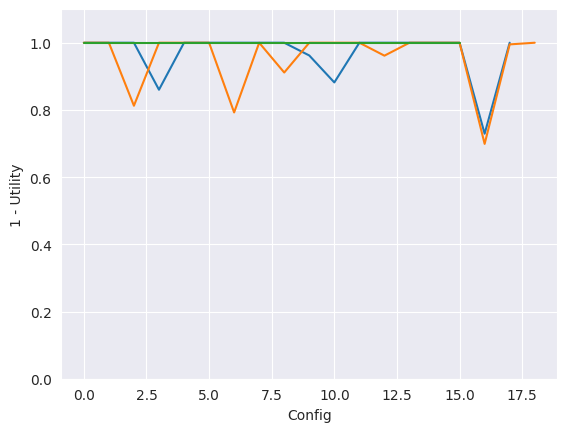

In [11]:
all_run = []
all_cost = []
n_configs_total = []

for i in range(1, 4):
    runt_array, cost_array = get_casmo_from_file(f"./wand_storage/CASMO_566/Full_DoE/{i}")

    plt.plot(cost_array, label=f"Run_{i}")

plt.ylim([0,1.1])
plt.xlabel("Config")
plt.ylabel("1 - Utility")
plt.show()


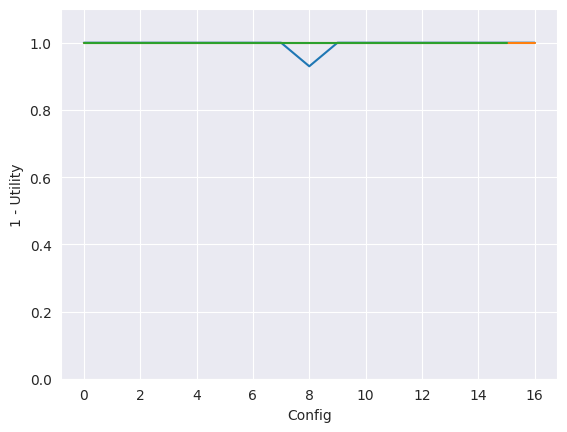

In [12]:
all_run = []
all_cost = []
n_configs_total = []

for i in range(1, 4):
    runt_array, cost_array = get_casmo_from_file(f"./wand_storage/CASMO_152/Full_DoE/{i}")

    plt.plot(cost_array, label=f"Run_{i}")

plt.ylim([0,1.1])
plt.xlabel("Config")
plt.ylabel("1 - Utility")
plt.show()


In [13]:
def make_conf_plot(file_loc):
    all_run = []
    all_cost = []
    n_configs_total = []

    for i in range(1, 4):
        runt_array, cost_array = get_casmo_from_file(f"{file_loc}/{i}")
        all_run.append(runt_array)
        all_cost.append(cost_array)


    y, error = tolerant_mean(all_cost)
    print(y)
    # ax.plot(np.arange(len(y))+1, y, color='green')

    ax = plt.figure().gca()

    ax.plot(np.arange(len(y))+1, y, color='purple')
    ax.fill_between(np.arange(len(y))+1, (y-error), (y+error), color='purple', alpha=.1)
    # plt.plot(cost_array, label=f"Run_{i}")
    plt.ylim([0,1.1])
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")

    # plt.set_major_locator(MaxNLocator(integer=True))
    # plt.xticks(np.arange(len(y))+1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

[1.0 1.0 0.9374893286091948 0.9533718363009774 1.0 1.0 0.9308300228370783
 1.0 0.970437011890442 0.9873467519530728 0.9605955246231677 1.0
 0.9871599574843528 1.0 1.0 1.0 0.7140658054645833 0.9975135129984516 1.0]


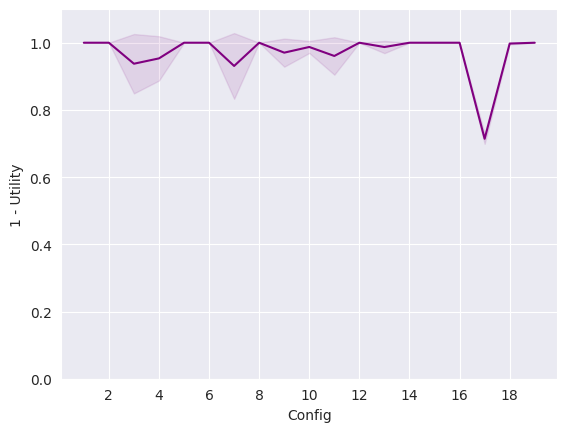

In [14]:
make_conf_plot("./wand_storage/CASMO_566/Full_DoE/")

[1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 0.9766285584205147 1.0 1.0 1.0 1.0 1.0
 1.0 1.0 1.0]


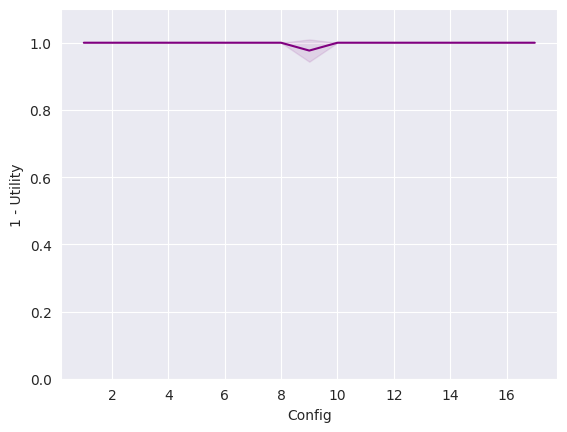

In [15]:
make_conf_plot("./wand_storage/CASMO_152/Full_DoE/")

# DefDoE


[0.3833292443317256 0.7890155639186082 0.7348766908601064
 0.6289148098864924 0.835509852315009 0.7369286278518995
 0.6655505977324183 0.47362921354045523 0.6387767228940889
 0.4846283212366321 0.6562427426964642 0.425002401919973
 0.7493550463989793 0.5289885617117158 0.5179841259856497
 0.6812244570367089 0.7672761748854823 0.8489912099841163
 0.6060045073716064 0.8093219309617657 0.7736995842285328
 0.44671138115222203 0.796296448877056 0.721178530706139
 0.5840802120830337 0.7040032272132484 0.48730492743606835
 0.5172321330382795 0.7109497096731214 0.5165429111555916
 0.5172072174592921 0.5728925947127715 0.5646850237362443
 0.7459073630034295 0.6746408138379646 0.7125610506507268
 0.8598709640405339 0.6071505466081597 0.49234050708439336
 0.759535258941928 0.6957009540970663 0.626020794804121 0.526936497909677
 0.42234920072975213 0.8078599161306219 0.37171088464081387
 0.9507633499478026 0.6101074058445325 0.441704680936422
 0.2533908253161564 0.3082842466241137]


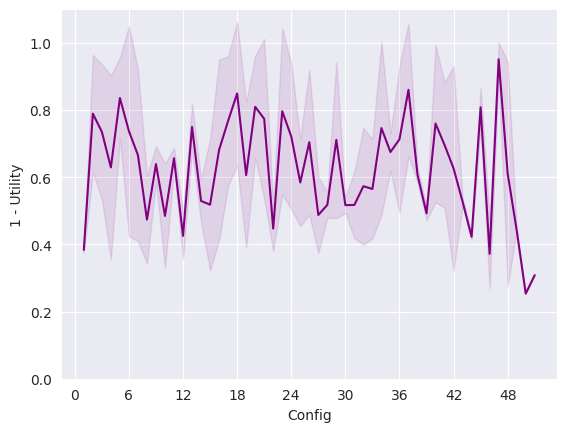

In [16]:
make_conf_plot("./wand_storage/CASMO_566/Def_DoE/")

[1.0 1.0 0.8855892109692194 1.0 1.0 1.0 0.9667838984203091 1.0
 0.9510524948377254 1.0 1.0 1.0 1.0 0.9855769376585227 1.0
 0.997734949636909 1.0 1.0]


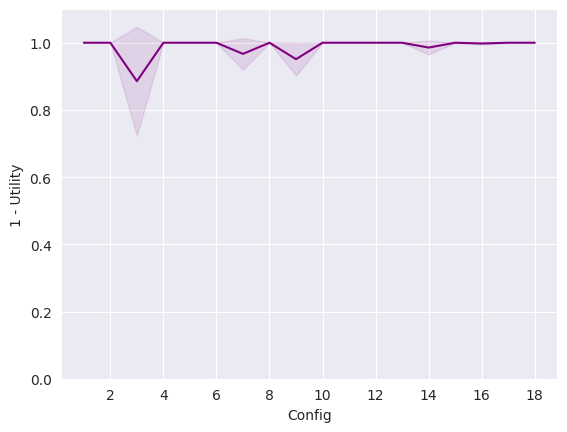

In [17]:
make_conf_plot("./wand_storage/CASMO_152/Def_DoE/")

# 23 SET CASMO

0.7906400648319409

In [36]:
def make_conf_plot_23_set(file_loc):
    all_run = []
    all_cost = []

    for i in range(1, 4):
        runt_array, cost_array = get_casmo_from_file(f"{file_loc}/{i}")
        all_run.append(runt_array)
        all_cost.append(cost_array)


    y, error = tolerant_mean(all_cost)

    ax = plt.figure().gca()

    ax.plot(np.arange(len(y))+1, y, color='purple')
    ax.fill_between(np.arange(len(y))+1, (y-error), (y+error), color='purple', alpha=.1)
    plt.hlines(0.7906400648319409,1, len(y), colors="red", linestyles=[":"]) #performance of default

    plt.ylim([0,1.1])
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")

    # plt.set_major_locator(MaxNLocator(integer=True))
    # plt.xticks(np.arange(len(y))+1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

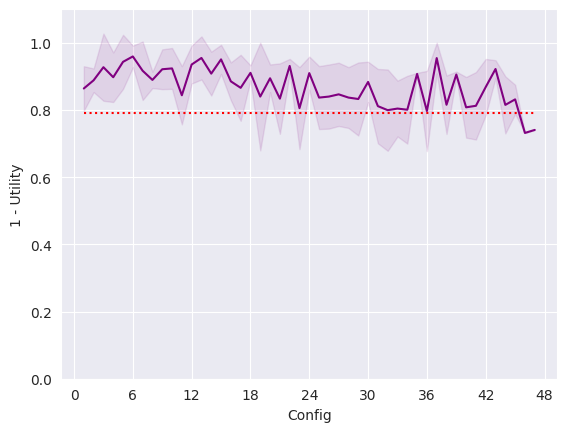

In [37]:
make_conf_plot_23_set("./wand_storage/23_CASMO")

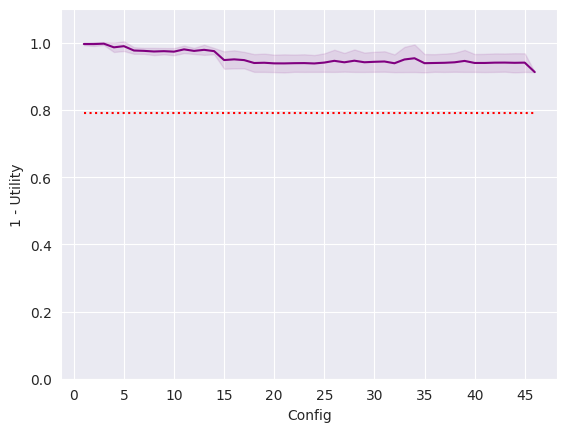

In [38]:
make_conf_plot_23_set("./wand_storage/23_BOUNCE")